# OOD 泛化評估：G5 / G7 / G8 三方對比

用爬蟲標注後拆分出的**真實新聞泛化測試集** `dataset/raw_scraped/ood_test.csv`（平衡集，
中英各半、label 0/1 各半），評估 G5 / G7 / G8 三個模型。

**指標**：Accuracy / Macro F1 / clickbait recall / false positive rate，
並報 **per-language（中/英）** 與 **per-site** 分面（防站點＝標籤捷徑，見 ANNOTATION_GUIDE）。

**前置**：
- `dataset/raw_scraped/ood_test.csv` 已由 `split_dataset.py` 產生
- `models/xlm-roberta-clickbait/`(G5)、`-g7/`(G7)、`-g8/`(G8) checkpoint
- **G8 未訓練時自動 skip**（沿用 explain_tokens 慣例）

> ⚠️ OOD 與主 test 的 domain/難度/標註者不同，**分數不可跨集互比**；此為平衡測試集（測區辨力，非真實部署分布）。
> 模糊樣本已標 keep=0 剔除，分數為上界。

## Step 1：載入 OOD 測試集（keep=1）

In [7]:
import io, sys, json
from pathlib import Path
import pandas as pd
if hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")

OOD_PATH = Path("../dataset/raw_scraped/ood_test.csv")
ood = pd.read_csv(OOD_PATH, dtype=str)
ood = ood[ood["keep"].astype(str) == "1"].copy()
ood["label"] = ood["label"].astype(int)
print(f"OOD 測試集：{len(ood)} 筆")
print("  四格分布：")
for lg in ["zh", "en"]:
    for lb in [0, 1]:
        n = ((ood["lang"] == lg) & (ood["label"] == lb)).sum()
        print(f"    {lg} label={lb}: {n}")
print("  per-site：", dict(ood["source_site"].value_counts()))

OOD 測試集：248 筆
  四格分布：
    zh label=0: 62
    zh label=1: 62
    en label=0: 62
    en label=1: 62
  per-site： {'dailymail': 49, 'setn': 40, 'buzzfeed': 32, 'kknews': 31, 'udn': 31, 'nypost': 29, 'ettoday': 22, 'bbc': 14}


## Step 2：三方預測 + 指標（Acc / Macro F1 / recall / FP率）

In [12]:
import sys
import importlib
import torch
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

sys.path.insert(0, str(Path.cwd()))
import dualtower
importlib.reload(dualtower)
from dualtower import ModelWrapper

MODELS = {
    "G5":   "../models/xlm-roberta-clickbait",
    "G7":   "../models/xlm-roberta-clickbait-g7",
    "G8":   "../models/xlm-roberta-clickbait-g8",
    "G9":   "../models/xlm-roberta-clickbait-g9-dualtower-run2",
}
THRESHOLD = 0.50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_all(wrapper, df, threshold=THRESHOLD, batch_size=32):
    titles   = df["title"].tolist()
    contents = [r.get("content", "") or "" for _, r in df.iterrows()]
    return wrapper.predict_batch(titles, contents, threshold=threshold, batch_size=batch_size)

def metrics(y, p):
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
    return {
        "accuracy": round(accuracy_score(y, p), 4),
        "macro_f1": round(f1_score(y, p, average="macro"), 4),
        "clickbait_recall": round(recall_score(y, p, pos_label=1, zero_division=0), 4),
        "fp_rate": round(fp / (fp + tn), 4) if (fp + tn) else 0.0,
        "n": len(y),
    }

results = {}
y_true = ood["label"].tolist()
for name, path in MODELS.items():
    if not Path(path).exists():
        print(f"[skip] {name} 模型不存在：{path}")
        continue
    arch = "dualtower" if (Path(path) / "classifier_head.pt").exists() else "single"
    print(f"[load] {name} ({arch}) ...")
    wrapper = ModelWrapper(name, path, device=DEVICE)
    preds = predict_all(wrapper, ood)
    ood[f"{name}_pred"] = preds
    results[name] = {"overall": metrics(y_true, preds)}
    print(f"  {name}: {results[name]['overall']}")
    wrapper.close()

[load] G5 (single) ...
  G5: {'accuracy': 0.6734, 'macro_f1': 0.6612, 'clickbait_recall': 0.4839, 'fp_rate': 0.1371, 'n': 248}
[load] G7 (single) ...


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G7: {'accuracy': 0.6855, 'macro_f1': 0.6743, 'clickbait_recall': 0.5, 'fp_rate': 0.129, 'n': 248}
[load] G8 (single) ...


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G8: {'accuracy': 0.7419, 'macro_f1': 0.7343, 'clickbait_recall': 0.5726, 'fp_rate': 0.0887, 'n': 248}
[load] G9 (dualtower) ...


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G9: {'accuracy': 0.754, 'macro_f1': 0.749, 'clickbait_recall': 0.6129, 'fp_rate': 0.1048, 'n': 248}


## Step 3：分面指標（per-language 中/英、per-site）

In [13]:
for name in list(results):
    pcol = f"{name}_pred"
    # per-language
    results[name]["per_lang"] = {}
    for lg in ["zh", "en"]:
        sub = ood[ood["lang"] == lg]
        if len(sub):
            results[name]["per_lang"][lg] = metrics(sub["label"].tolist(), sub[pcol].tolist())
    # per-site
    results[name]["per_site"] = {}
    for site in sorted(ood["source_site"].unique()):
        sub = ood[ood["source_site"] == site]
        if len(sub):
            results[name]["per_site"][site] = metrics(sub["label"].tolist(), sub[pcol].tolist())

print("=== per-language Macro F1 ===")
for name in results:
    pl = results[name]["per_lang"]
    print(f"  {name}: " + " | ".join(f"{lg} F1={pl[lg]['macro_f1']}" for lg in pl))
print("\n=== per-site Macro F1 ===")
for name in results:
    print(f"  {name}:")
    for site, m in results[name]["per_site"].items():
        print(f"    {site:10} F1={m['macro_f1']} (n={m['n']}, FP={m['fp_rate']})")

Path("../results").mkdir(exist_ok=True)
with open("../results/ood_eval_3way.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print("\n結果存：results/ood_eval_3way.json")

=== per-language Macro F1 ===
  G5: zh F1=0.7309 | en F1=0.5814
  G7: zh F1=0.711 | en F1=0.636
  G8: zh F1=0.8046 | en F1=0.6574
  G9: zh F1=0.8465 | en F1=0.6402

=== per-site Macro F1 ===
  G5:
    bbc        F1=0.4167 (n=14, FP=0.2308)
    buzzfeed   F1=0.8436 (n=32, FP=0.1875)
    dailymail  F1=0.4896 (n=49, FP=0.0)
    ettoday    F1=0.7054 (n=22, FP=0.0)
    kknews     F1=0.6601 (n=31, FP=0.3)
    nypost     F1=0.3655 (n=29, FP=0.0909)
    setn       F1=0.7995 (n=40, FP=0.1176)
    udn        F1=0.6043 (n=31, FP=0.2083)
  G7:
    bbc        F1=0.44 (n=14, FP=0.1538)
    buzzfeed   F1=0.8095 (n=32, FP=0.3125)
    dailymail  F1=0.6048 (n=49, FP=0.0)
    ettoday    F1=0.646 (n=22, FP=0.0)
    kknews     F1=0.6392 (n=31, FP=0.2)
    nypost     F1=0.4141 (n=29, FP=0.0909)
    setn       F1=0.7749 (n=40, FP=0.1176)
    udn        F1=0.631 (n=31, FP=0.1667)
  G8:
    bbc        F1=0.4167 (n=14, FP=0.2308)
    buzzfeed   F1=0.8436 (n=32, FP=0.125)
    dailymail  F1=0.6806 (n=49, FP=0.0)


## Step 4：三方對比柱狀圖（總體 + per-language）

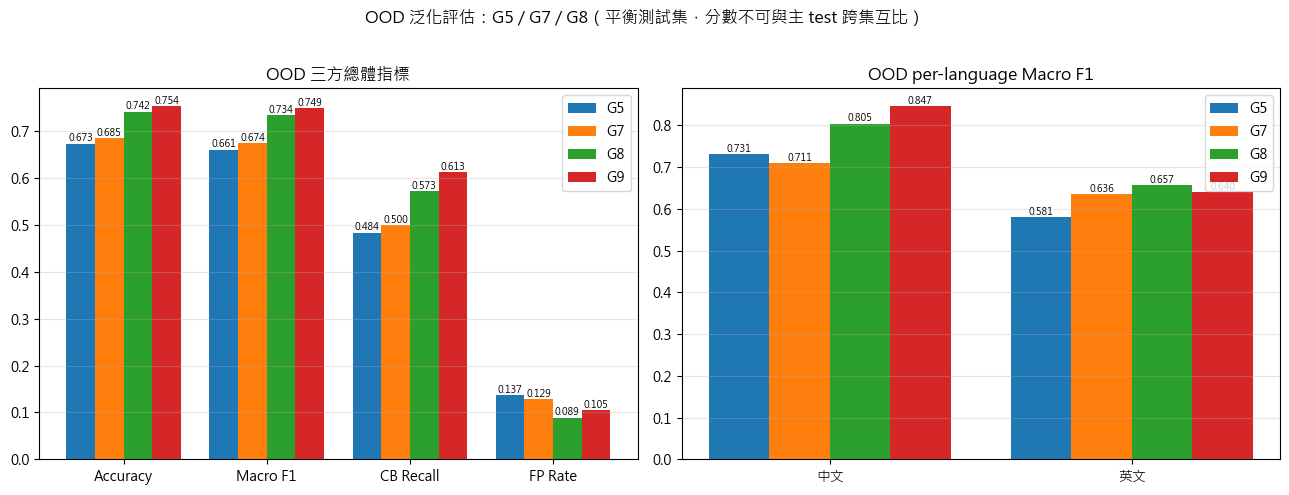

圖存：..\results\ood_eval_3way.png


In [14]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
matplotlib.rcParams["axes.unicode_minus"] = False

names = list(results)
if names:
    # 總體：Acc / Macro F1 / recall / FP率
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    metr = ["accuracy", "macro_f1", "clickbait_recall", "fp_rate"]
    x = range(len(metr))
    w = 0.8 / len(names)
    for i, name in enumerate(names):
        vals = [results[name]["overall"][m] for m in metr]
        bars = axes[0].bar([xi + i * w for xi in x], vals, w, label=name)
        for b, v in zip(bars, vals):
            axes[0].text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                         ha="center", fontsize=7)
    axes[0].set_xticks([xi + w * (len(names) - 1) / 2 for xi in x])
    axes[0].set_xticklabels(["Accuracy", "Macro F1", "CB Recall", "FP Rate"])
    axes[0].set_title("OOD 三方總體指標")
    axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

    # per-language Macro F1
    langs = ["zh", "en"]
    xl = range(len(langs))
    for i, name in enumerate(names):
        vals = [results[name]["per_lang"].get(lg, {}).get("macro_f1", 0) for lg in langs]
        bars = axes[1].bar([xi + i * w for xi in xl], vals, w, label=name)
        for b, v in zip(bars, vals):
            axes[1].text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                         ha="center", fontsize=7)
    axes[1].set_xticks([xi + w * (len(names) - 1) / 2 for xi in xl])
    axes[1].set_xticklabels(["中文", "英文"])
    axes[1].set_title("OOD per-language Macro F1")
    axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

    fig.suptitle("OOD 泛化評估：G5 / G7 / G8（平衡測試集，分數不可與主 test 跨集互比）", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out = Path("../results/ood_eval_3way.png")
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"圖存：{out}")
else:
    print("無可用模型")

## OOD 註記（報告引用時必附）

- **平衡測試集**：label 0/1 各半、中英各半，測模型區辨力，非真實部署分布。
- **不可跨集互比**：OOD 與主 test 的 domain/難度/標註者不同，分數只在 OOD 集內比較 G5/G7/G8。
- **分數為上界**：模糊樣本已標 keep=0 剔除。
- **per-site / source-held-out**：檢驗模型學的是標題黨特徵而非站點文風捷徑。

## Step 5：主 test set Macro F1 三方對比（G5 / G7 / G8）

主 test set 是各模型訓練時的同分布測試集（stratified split）。G8 的數值待訓練後填入下方
`MAIN_TEST_MACRO_F1` 字典（G2-G7 為已發表結果）。訊息是「G8 沒犧牲主榜」，非「G8 贏」。

> ⚠️ 與上方 OOD 是**不同測試集**，不可互比；y 軸從 0.86 起跳（差距小），caption 須註明截斷。

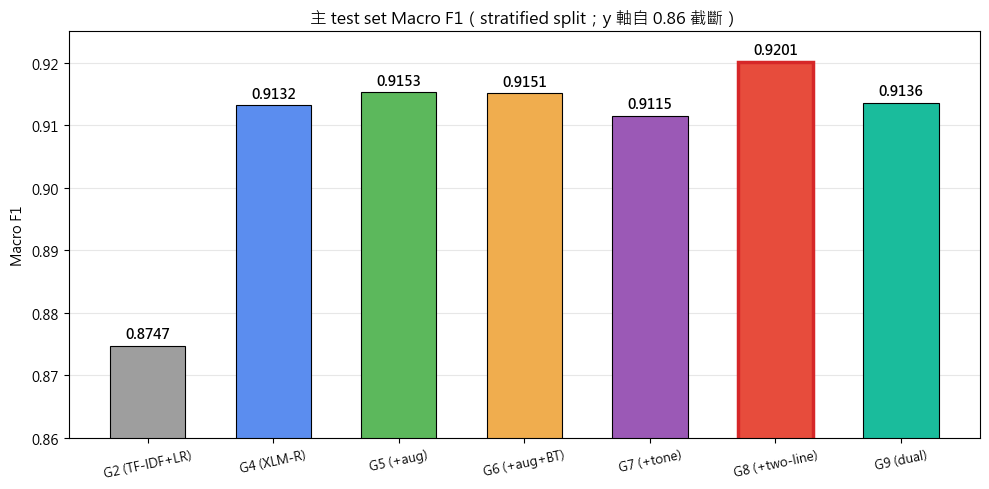

圖存：..\results\main_test_macro_f1_comparison.png  G8=0.9201  G9v2=待訓練


In [ ]:
import matplotlib.pyplot as plt

MAIN_TEST_MACRO_F1 = {
    "G2 (TF-IDF+LR)":   0.8747,
    "G4 (XLM-R)":       0.9132,
    "G5 (+aug)":        0.9153,
    "G6 (+aug+BT)":     0.9151,
    "G7 (+tone)":       0.9115,
    "G8 (+two-line)":   0.9201,
    "G9 (dual)":        0.9136,
}
labels = [k for k, v in MAIN_TEST_MACRO_F1.items() if v is not None]
vals   = [v for v in MAIN_TEST_MACRO_F1.values()   if v is not None]

palette = ["#9e9e9e", "#5b8def", "#5cb85c", "#f0ad4e", "#9b59b6", "#e74c3c", "#1abc9c", "#16a085"]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(labels)), vals, width=0.6, edgecolor="black", linewidth=0.8,
              color=palette[:len(labels)])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.0012, f"{v:.4f}",
            ha="center", fontsize=10, fontweight="bold")
best = vals.index(max(vals))
bars[best].set_edgecolor("#d62728"); bars[best].set_linewidth(2.5)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9, rotation=12)
ax.set_ylabel("Macro F1"); ax.set_ylim(0.86, 0.925)
ax.set_title("主 test set Macro F1（stratified split；y 軸自 0.86 截斷）")
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
fig.tight_layout()
out = Path("../results/main_test_macro_f1_comparison.png")
fig.savefig(out, dpi=150); plt.show()
g9v2_val = MAIN_TEST_MACRO_F1.get("G9v2 (C1+C2+C3)")
print(f"圖存：{out}  G8={MAIN_TEST_MACRO_F1['G8 (+two-line)']}  G9v2={'待訓練' if g9v2_val is None else g9v2_val}")

## Step 6：regression_test 三方對比（G5 / G7 / G8）

人工/查證的回歸探針（14 筆，按 bug 分組），看哪些案例 ❌→✅、舊對的沒退步。
**非真實 FP 率統計**（那用 OOD），是「有沒有退步」的回歸測試。G8 未訓練自動 skip。

In [15]:
rt = pd.read_csv("../dataset/processed/regression_test.csv")
print(f"regression_test：{len(rt)} 筆")

def predict_rt(name, path, df, threshold=THRESHOLD):
    if not Path(path).exists():
        return None
    wrapper = ModelWrapper(name, path, device=DEVICE)
    out = [wrapper.predict(r["title"], r.get("content", "") or "", threshold)
           for _, r in df.iterrows()]
    wrapper.close()
    return out

for name, path in MODELS.items():
    preds = predict_rt(name, path, rt)
    if preds is None:
        print(f"[skip] {name}")
        continue
    rt[f"{name}_pred"] = preds
    rt[f"{name}_ok"] = (rt[f"{name}_pred"] == rt["label"])
    print(f"  {name}: 對 {rt[f'{name}_ok'].sum()}/{len(rt)}")

# ✅/❌ 矩陣（按 error_type 分組）
ok_cols = [f"{n}_ok" for n in MODELS if f"{n}_ok" in rt.columns]
show = rt[["id", "error_type", "label"] + ok_cols].copy()
for c in ok_cols:
    show[c] = show[c].map({True: "✅", False: "❌"})
print("\n=== regression 結果矩陣 ===")
print(show.to_string(index=False))
rt.to_csv("../results/regression_3way.csv", index=False, encoding="utf-8-sig")
print("\n存：results/regression_3way.csv")

regression_test：14 筆


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G5: 對 11/14


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G7: 對 9/14


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G8: 對 10/14


c:\Users\tjx20\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  G9: 對 9/14

=== regression 結果矩陣 ===
                 id   error_type  label G5_ok G7_ok G8_ok G9_ok
       rt_zh_001_3B           FP      0     ❌     ✅     ✅     ✅
       rt_zh_001_3A           FN      1     ✅     ✅     ✅     ✅
          rt_zh_003           FN      1     ✅     ❌     ❌     ❌
       rt_zh_002_3B           FP      0     ❌     ❌     ✅     ✅
     rt_zh_b1_gator     FP_check      0     ✅     ✅     ✅     ✅
     rt_zh_b1_ramen     FP_check      0     ✅     ✅     ✅     ❌
     rt_en_b1_gator     FP_check      0     ✅     ✅     ✅     ✅
      rt_en_b1_tank     FP_check      0     ✅     ✅     ✅     ✅
rt_en_b1_gator_bait     baseline      1     ✅     ✅     ✅     ✅
     rt_zh_b4_sleep           FN      1     ✅     ❌     ❌     ❌
     rt_zh_b4_space           FN      1     ✅     ❌     ❌     ❌
    rt_en_b4_invest           FN      1     ❌     ❌     ❌     ❌
 rt_zh_b4_cu_normal content_util      1     ✅     ✅     ✅     ✅
  rt_zh_b4_cu_empty content_util      1     ✅     ✅     ✅     ✅

存

## 三項評估彙整（PLAN §5）

| 評估 | 測什麼 | 本 notebook |
|------|--------|------------|
| **OOD 三方**（Step 1-4） | 真實新聞泛化（平衡集，per-lang/site） | ✅ 主評估 |
| **主 test 三方**（Step 5） | G8 沒犧牲主榜 | ✅ 待填 G8 數值 |
| **regression 三方**（Step 6） | ❌→✅、舊的沒退步 | ✅ G8 自動偵測 |

搭配`explain_tokens.py`（token 歸因）完成完整評估。